In [ ]:
# SESIÓN 5 – MANIPULACIÓN DE DATOS CON PANDAS

# Importar librerías necesarias
import pandas as pd
import numpy as np

In [ ]:
# 1. ÍNDICES JERÁRQUICOS (multiíndices)
# -----------------------------------------
print("=== 1. Índices Jerárquicos ===")

df = pd.DataFrame({
    "Region": ["Norte", "Norte", "Sur", "Sur"],
    "Ciudad": ["Arica", "Iquique", "Temuco", "Valdivia"],
    "Ventas": [100, 150, 200, 120]
})

# Convertir columnas en índices jerárquicos
df_hier = df.set_index(["Region", "Ciudad"])
print(df_hier)

# Crea un DataFrame con 3 columnas:
# Region: indica si la ciudad está en el Norte o en el Sur.
# Ciudad: nombre de la ciudad.
# Ventas: cantidad de ventas en esa ciudad.
# df.set_index(["Region", "Ciudad"]):
# Esto transforma las columnas Region y Ciudad en índices jerárquicos.
# El DataFrame resultante ya no tiene esas dos columnas como parte de las columnas principales, sino como parte del índice (fila identificadora).
# ¿PARA QUÉ SIRVE UN ÍNDICE JERÁRQUICO?
# Es útil para trabajar con datos agrupados o jerarquizados, por ejemplo:
# Cuando quieres analizar ventas por región y ciudad.
# Cuando haces operaciones como .groupby(), .loc[], .unstack(), o .xs() para acceder a niveles del índice.
# Permite una navegación más precisa y ordenada de datos con múltiples niveles.

=== 1. Índices Jerárquicos ===
                 Ventas
Region Ciudad          
Norte  Arica        100
       Iquique      150
Sur    Temuco       200
       Valdivia     120


In [ ]:
# 2. AGRUPAMIENTO con groupby
# -----------------------------------------
print("\n=== 2. Agrupamiento groupby ===")

# Crear un DataFrame con datos de ventas por año y ciudad
df_group = pd.DataFrame({
    "Ciudad": ["Santiago", "Santiago", "Valparaíso", "Valparaíso", "Temuco", "Temuco"],
    "Año": [2023, 2024, 2023, 2024, 2023, 2024],
    "Ventas": [1000, 1200, 800, 950, 500, 600]
})

# Agrupar por ciudad y calcular la media de ventas
print(df_group.groupby("Ciudad")["Ventas"].mean())
# Esto agrupa las filas del DataFrame por el valor que aparece en la columna "Ciudad",
# y luego calcula el promedio (con .mean()) de la columna "Ventas" para cada ciudad.

# .groupby() es una de las herramientas más poderosas de pandas para análisis de datos.
# Permite hacer resúmenes estadísticos por grupos:
# Promedios, sumas, conteos, máximos, mínimos, desviaciones, etc.
# También sirve para agrupar por una o más columnas.


=== 2. Agrupamiento groupby ===
Ciudad
Santiago      1100.0
Temuco         550.0
Valparaíso     875.0
Name: Ventas, dtype: float64


In [ ]:
# 3. TABLA DINÁMICA con pivot_table
# -----------------------------------------
print("\n=== 3. Tabla dinámica con pivot_table ===")

pivot = df_group.pivot_table(index="Ciudad", columns="Año", values="Ventas")
print(pivot)

# pivot_table en pandas es similar a una tabla dinámica de Excel.
# Toma un DataFrame y lo reorganiza para que puedas ver los datos resumidos por filas y columnas específicas.
# ¿QUÉ HACE CADA PARTE?
# index="Ciudad" → las filas serán las ciudades.

# columns="Año" → las columnas serán los años.

# values="Ventas" → los valores numéricos mostrados serán las ventas.




=== 3. Tabla dinámica con pivot_table ===
Año           2023    2024
Ciudad                    
Santiago    1000.0  1200.0
Temuco       500.0   600.0
Valparaíso   800.0   950.0


In [ ]:
# 4. TRANSFORMACIÓN de ancho a largo con melt
# -----------------------------------------
print("\n=== 4. Transformación con melt ===")

df_ancho = pd.DataFrame({
    "Ciudad": ["Santiago", "Temuco"],
    "2023": [1000, 500],
    "2024": [1200, 600]
})

# Convertir columnas de año en filas
df_largo = df_ancho.melt(id_vars="Ciudad", var_name="Año", value_name="Ventas")  # Usamos melt para transformar el formato
print(df_largo)  #  'Ciudad' se mantiene como está, Las columnas (2023, 2024) se pasan a una nueva columna llamada 'Año'
# Los valores asociados se pasan a una nueva columna llamada 'Ventas'

# melt convierte un DataFrame ancho (wide) en uno largo (long). Es decir, transforma
# las columnas en filas. Es muy útil para reestructurar los datos cuando necesitas analizarlos
# o graficarlos más fácilmente.

# ¿Cuándo usar melt()?
# Cuando necesitas reorganizar los datos para facilitar gráficos, análisis o agrupamientos.
# Para transformar resultados de un pivot_table de nuevo a su forma original.
# En modelos estadísticos o de ML que requieren formato largo.


=== 4. Transformación con melt ===
     Ciudad   Año  Ventas
0  Santiago  2023    1000
1    Temuco  2023     500
2  Santiago  2024    1200
3    Temuco  2024     600


In [ ]:
# 5. CONCATENACIÓN VERTICAL con concat
# -----------------------------------------
print("\n=== 5. Unión vertical con concat ===") # CONCATENACIÓN VERTICAL con concat

df1 = pd.DataFrame({"Nombre": ["Ana", "Luis"], "Edad": [25, 30]}) # Se crean dos DataFrame separados:
df2 = pd.DataFrame({"Nombre": ["Carlos", "Marta"], "Edad": [28, 27]})

df_concat = pd.concat([df1, df2]) # Unir los dos DataFrames uno debajo del otro, los une verticalmente, es decir, apila uno debajo del otro:
print(df_concat)

# Esto demuestra cómo unir dos DataFrame uno debajo del otro, usando pd.concat(). Este proceso se conoce como concatenación vertical.
# ¿Cuándo usar concatenación vertical?
# Cuando tienes datos de diferentes períodos o fuentes pero con las mismas columnas.
# Para juntar resultados de encuestas, registros, etc.


=== 5. Unión vertical con concat ===
   Nombre  Edad
0     Ana    25
1    Luis    30
0  Carlos    28
1   Marta    27


In [ ]:
# 6. UNIÓN HORIZONTAL con merge
# -----------------------------------------
print("\n=== 6. Combinación horizontal con merge ===")

clientes = pd.DataFrame({
    "ID": [1, 2, 3],
    "Nombre": ["Ana", "Luis", "Carlos"]
})

compras = pd.DataFrame({
    "ID": [1, 2, 4],
    "Producto": ["Laptop", "Celular", "Tablet"]
})
# Se crean dos DataFrames:

# Combinar por ID con outer join
# pd.merge(..., how="outer") combina ambos por la columna "ID" usando un outer join, lo que significa:
# Incluir todas las filas de ambos DataFrames.
# Si no hay coincidencia en el otro DataFrame, se completa con NaN.
df_merged = pd.merge(clientes, compras, on="ID", how="outer")
print(df_merged)
# ¿Cuándo usar merge()?
# Para unir información relacionada por una columna común (clave), como IDs, códigos, etc.
# Muy útil cuando tienes bases separadas, como:
# Clientes y sus pedidos
# Estudiantes y sus notas
# Productos y sus precios

# Aquí se muestra cómo unir dos tablas horizontalmente usando la función pd.merge() de pandas.
# Este procedimiento se llama combinación horizontal o join, muy similar a las uniones en bases de datos (como SQL).


=== 6. Combinación horizontal con merge ===
   ID  Nombre Producto
0   1     Ana   Laptop
1   2    Luis  Celular
2   3  Carlos      NaN
3   4     NaN   Tablet


In [ ]:
# 7. CORTE Y SELECCIÓN DE DATOS CON loc[]
# --------------------------------------------
import pandas as pd

# Creamos un DataFrame de ejemplo
personas = pd.DataFrame({
    "Nombre": ["Ana", "Luis", "Carlos", "Marta", "Sofía"],
    "Edad": [25, 30, 28, 27, 24],
    "Ciudad": ["Santiago", "Valparaíso", "Concepción", "Temuco", "Iquique"],
    "Genero": ["F", "M", "M", "F", "F"]
})
# Establecer la columna "Nombre" como índice
personas.set_index("Nombre", inplace=True)

print("\n=== 7. Selección con loc[] ===")


=== 7. Selección con loc[] ===


In [ ]:
# Seleccionar una fila específica por el índice (etiqueta)
print("\nDatos de Marta:")
print(personas.loc["Marta"])


Datos de Marta:
Edad          27
Ciudad    Temuco
Genero         F
Name: Marta, dtype: object


In [ ]:
# Seleccionar varias filas por etiqueta
print("\nDatos de Ana y Sofía:")
print(personas.loc[["Ana", "Sofía"]])


Datos de Ana y Sofía:
        Edad    Ciudad Genero
Nombre                       
Ana       25  Santiago      F
Sofía     24   Iquique      F


In [ ]:
# Seleccionar filas y columnas por etiquetas
print("\nEdad y Ciudad de Luis y Carlos:")
print(personas.loc[["Luis", "Carlos"], ["Edad", "Ciudad"]])


Edad y Ciudad de Luis y Carlos:
        Edad      Ciudad
Nombre                  
Luis      30  Valparaíso
Carlos    28  Concepción


In [ ]:
# Filtrar con condición
print("\nPersonas con Edad > 26:")
print(personas.loc[personas["Edad"] > 26])


Personas con Edad > 26:
        Edad      Ciudad Genero
Nombre                         
Luis      30  Valparaíso      M
Carlos    28  Concepción      M
Marta     27      Temuco      F


loc[] permite:

Seleccionar una fila o conjunto de filas por su índice o nombre.

Seleccionar columnas específicas por su etiqueta.

Filtrar filas según condiciones lógicas.

Modificar valores directamente.
.loc[fila] → devuelve una fila.

.loc[fila, columna] → devuelve un valor específico.

.loc[condición] → filtra filas que cumplan una condición.

.loc[filas, columnas] → devuelve un subconjunto.



In [ ]:
# Análisis de situación con múltiples herramientas
# Supón que tienes el siguiente DataFrame de ventas anuales:
import pandas as pd

df = pd.DataFrame({
    "Ciudad": ["Santiago", "Temuco", "Santiago", "Temuco", "Valparaíso", "Valparaíso"],
    "Año": [2022, 2022, 2023, 2023, 2022, 2023],
    "Ventas": [950, 720, 1100, 800, 870, 920]
})
print("=== DataFrame Original ===")
print(df)
# a) Crea una tabla dinámica (pivot_table) donde las ciudades estén como índices y los años como columnas, mostrando el total de ventas.

=== DataFrame Original ===
       Ciudad   Año  Ventas
0    Santiago  2022     950
1      Temuco  2022     720
2    Santiago  2023    1100
3      Temuco  2023     800
4  Valparaíso  2022     870
5  Valparaíso  2023     920


In [ ]:
# a) Crear tabla dinámica (pivot_table)
pivot = df.pivot_table(index="Ciudad", columns="Año", values="Ventas", aggfunc="sum")

print("\n=== a) Tabla dinámica con total de ventas por ciudad y año ===")
print(pivot)


=== a) Tabla dinámica con total de ventas por ciudad y año ===
Año         2022  2023
Ciudad                
Santiago     950  1100
Temuco       720   800
Valparaíso   870   920


In [ ]:
# b) Transforma esta tabla dinámica a formato largo (usando melt) y ordena las filas por ciudad y año.
df_largo = pivot.reset_index().melt(id_vars="Ciudad", var_name="Año", value_name="Ventas")

print("\n=== b) Tabla en formato largo ===")
print(df_largo.sort_values(by=["Ciudad", "Año"]))


=== b) Tabla en formato largo ===
       Ciudad   Año  Ventas
0    Santiago  2022     950
3    Santiago  2023    1100
1      Temuco  2022     720
4      Temuco  2023     800
2  Valparaíso  2022     870
5  Valparaíso  2023     920


In [ ]:
# c) Finalmente, filtra el resultado para mostrar solo los registros donde las ventas sean mayores a 900.
df_filtrado = df_largo[df_largo["Ventas"] > 900]

print("\n=== c) Filtrar ventas mayores a 900 ===")
print(df_filtrado.sort_values(by=["Ciudad", "Año"]))


=== c) Filtrar ventas mayores a 900 ===
       Ciudad   Año  Ventas
0    Santiago  2022     950
3    Santiago  2023    1100
5  Valparaíso  2023     920


In [ ]:
# Actividad práctica: Análisis de ventas por región y producto
# SESIÓN 5 Actividad integradora
# Transformaciones con pandas
# ===============================

import pandas as pd

# Paso 1: Crear un DataFrame en formato ancho con ventas por región y producto
df_ancho = pd.DataFrame({
    "Región": ["Norte", "Centro", "Sur"],
    "Producto A": [1200, 1500, 1100],
    "Producto B": [800, 1300, 1000],
    "Producto C": [500, 600, 700]
})

print("=== 1. Datos en formato ancho ===")
print(df_ancho)

=== 1. Datos en formato ancho ===
   Región  Producto A  Producto B  Producto C
0   Norte        1200         800         500
1  Centro        1500        1300         600
2     Sur        1100        1000         700


In [ ]:
# Paso 2: Transformar a formato largo con melt
df_largo = df_ancho.melt(id_vars="Región", var_name="Producto", value_name="Ventas")
print("\n=== 2. Formato largo con melt ===")
print(df_largo)


=== 2. Formato largo con melt ===
   Región    Producto  Ventas
0   Norte  Producto A    1200
1  Centro  Producto A    1500
2     Sur  Producto A    1100
3   Norte  Producto B     800
4  Centro  Producto B    1300
5     Sur  Producto B    1000
6   Norte  Producto C     500
7  Centro  Producto C     600
8     Sur  Producto C     700


In [ ]:
# Paso 3: Crear tabla dinámica (pivot_table) con Región como índice
pivot = df_largo.pivot_table(index="Región", columns="Producto", values="Ventas")
print("\n=== 3. Tabla dinámica con pivot_table ===")
print(pivot)


=== 3. Tabla dinámica con pivot_table ===
Producto  Producto A  Producto B  Producto C
Región                                      
Centro        1500.0      1300.0       600.0
Norte         1200.0       800.0       500.0
Sur           1100.0      1000.0       700.0


In [ ]:
# Paso 4: Filtrar regiones con ventas mayores a 1000 para Producto B
filtro = df_largo[(df_largo["Producto"] == "Producto B") & (df_largo["Ventas"] > 1000)]
print("\n=== 4. Regiones con ventas > 1000 en Producto B ===")
print(filtro)


=== 4. Regiones con ventas > 1000 en Producto B ===
   Región    Producto  Ventas
4  Centro  Producto B    1300


In [ ]:
# Paso 5: Agrupar por producto y calcular promedio de ventas
promedios = df_largo.groupby("Producto")["Ventas"].mean()
print("\n=== 5. Promedio de ventas por producto ===")
print(promedios)


=== 5. Promedio de ventas por producto ===
Producto
Producto A    1266.666667
Producto B    1033.333333
Producto C     600.000000
Name: Ventas, dtype: float64


In [ ]:
# Paso 6: Concatenar nuevos datos (nueva región)
nueva_region = pd.DataFrame({
    "Región": ["Patagonia"],
    "Producto A": [950],
    "Producto B": [700],
    "Producto C": [600]
})

df_actualizado = pd.concat([df_ancho, nueva_region], ignore_index=True)
print("\n=== 6. Concatenación vertical con nueva región ===")
print(df_actualizado)


=== 6. Concatenación vertical con nueva región ===
      Región  Producto A  Producto B  Producto C
0      Norte        1200         800         500
1     Centro        1500        1300         600
2        Sur        1100        1000         700
3  Patagonia         950         700         600


In [ ]:
# Paso 7: Merge de información adicional
info_region = pd.DataFrame({
    "Región": ["Norte", "Centro", "Sur", "Patagonia"],
    "Gerente": ["Laura", "Pedro", "Ana", "Miguel"]
})

df_merge = pd.merge(df_actualizado, info_region, on="Región", how="left")
print("\n=== 7. Merge con información adicional ===")
print(df_merge)


=== 7. Merge con información adicional ===
      Región  Producto A  Producto B  Producto C Gerente
0      Norte        1200         800         500   Laura
1     Centro        1500        1300         600   Pedro
2        Sur        1100        1000         700     Ana
3  Patagonia         950         700         600  Miguel


In [ ]:
# Ejemplo: Ventas por Ciudad y Año con Gráfico de Barras
# Paso 1: Importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paso 2: Crear un DataFrame en formato largo
df = pd.DataFrame({
    "Ciudad": ["Santiago", "Temuco", "Valparaíso", "Santiago", "Temuco", "Valparaíso"],
    "Año": [2023, 2023, 2023, 2024, 2024, 2024],
    "Ventas": [2500, 1800, 2200, 2700, 1900, 2300]
})


In [ ]:
# Paso 3: Crear una tabla dinámica con pivot_table
tabla = df.pivot_table(index="Ciudad", columns="Año", values="Ventas")

# Paso 4: Mostrar tabla y gráfico
print("Tabla dinámica:\n")
print(tabla)

Tabla dinámica:

Año           2023    2024
Ciudad                    
Santiago    2500.0  2700.0
Temuco      1800.0  1900.0
Valparaíso  2200.0  2300.0


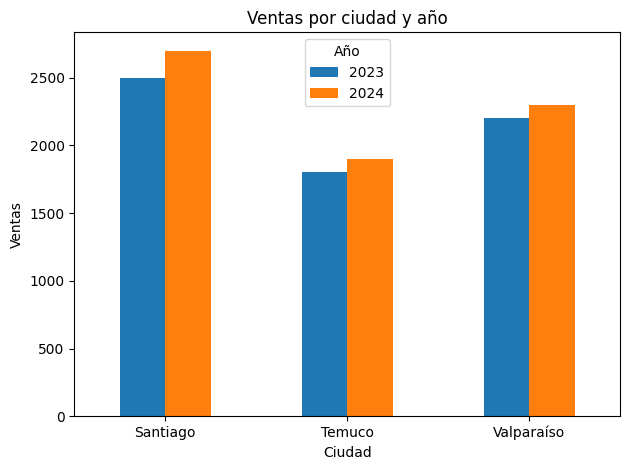

In [ ]:
# Paso 5: Gráfico de barras comparando años
tabla.plot(kind="bar")
plt.title("Ventas por ciudad y año")
plt.ylabel("Ventas")
plt.xlabel("Ciudad")
plt.xticks(rotation=0)
plt.legend(title="Año")
plt.tight_layout()
plt.show()

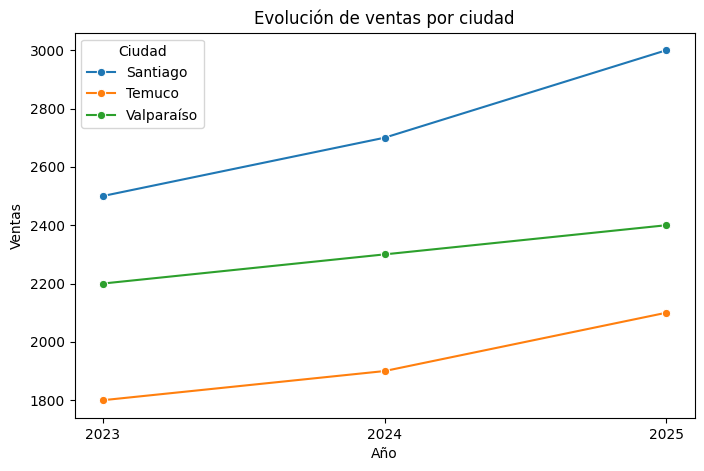

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Datos en formato largo
df_largo = pd.DataFrame({
    "Ciudad": ["Santiago", "Temuco", "Valparaíso"] * 3,
    "Año": ["2023"]*3 + ["2024"]*3 + ["2025"]*3,
    "Ventas": [2500, 1800, 2200, 2700, 1900, 2300, 3000, 2100, 2400]
})

# Gráfico de línea
plt.figure(figsize=(8,5))
sns.lineplot(data=df_largo, x="Año", y="Ventas", hue="Ciudad", marker="o")
plt.title("Evolución de ventas por ciudad")
plt.ylabel("Ventas")
plt.show()

# **Actividad**
Parte 1: Preguntas de opción múltiple (selección única)
1. ¿Qué hace la función melt() en pandas?
a) Ordena las columnas alfabéticamente
**b) Transforma datos de formato ancho a formato largo**
c) Combina columnas duplicadas
d) Elimina columnas con valores nulos

2. ¿Cuál es la diferencia entre pivot() y pivot_table()?
a) pivot_table no permite agrupación
b) pivot solo sirve para gráficos
**c) pivot_table permite agregación (ej. promedios), mientras que pivot no**
d) pivot_table no existe en pandas

3. ¿Cuál es la función de concat() en pandas?
a) Suma los valores de un DataFrame
b) Borra filas duplicadas
c) Une DataFrames por columnas comunes
**d) Une DataFrames por filas o columnas**

4. En un merge() con how="outer", ¿qué sucede si hay valores que no coinciden entre los dos DataFrames?
a) Se eliminan automáticamente
**b) Se agregan como filas con NaN donde no hay coincidencias**
c) Solo se conservan las coincidencias exactas
d) Los valores duplicados se suman

Paso 1: Crear los datos base
import pandas as pd

# Crear un DataFrame en formato ancho
df_ancho = pd.DataFrame({
    "Ciudad": ["Santiago", "Temuco", "Valparaíso"],
    "2023": [2500, 1800, 2200],
    "2024": [2700, 1900, 2300],
    "2025": [3000, 2100, 2400]
})

print(" Datos en formato ancho:")
print(df_ancho)

Paso 2: Transformar el formato ancho a largo con melt()
Transformar columnas de años en filas

Paso 3: Crear una tabla dinámica con pivot_table.
Crear tabla dinámica con ciudades como índice y años como columnas.

 Paso 4: Filtrar las ciudades con ventas mayores a 2000 en 2024 usando .loc

 Paso 5: Agrupamiento con groupby (opcional)
 Agrupar por ciudad y calcular promedio de ventas.

 Paso 6: Concatenar dos DataFrames de ciudades.
 Crear dos pequeños DF

 Paso 7: Merge entre clientes y compras.
 Si realizamos un merge() entre dos DataFrames con how="outer", ¿qué ventajas tiene frente a how="inner"?

 Pregunta 8: ¿Qué ciudad tuvo el mayor crecimiento en ventas entre 2023 y 2025?

 Pregunta 9: ¿Cuál es el promedio de ventas por año en todas las ciudades?

 Pregunta 10. ¿Qué ciudad tuvo un crecimiento constante durante los tres años?
Explica tu respuesta basándote en la comparación visual de las barras en el gráfico.



In [ ]:
# PASO I : Crear los datos base import pandas as pd

import pandas as pd

#Crear un DataFrame en formato ancho
DF_ancho = pd.DataFrame({ "Ciudad": ["Santiago", "Temuco", "Valparaíso"], "2023": [2500, 1800, 2200], "2024": [2700, 1900, 2300], "2025": [3000, 2100, 2400] })

print("DATOS EN FORMATO ANCHO")
display(DF_ancho)


DATOS EN FORMATO ANCHO


,Ciudad,2023,2024,2025
0,Santiago,2500,2700,3000
1,Temuco,1800,1900,2100
2,Valparaíso,2200,2300,2400


In [ ]:
# PASO II : Transformar el formato ancho a largo con melt() Transformar columnas de años en filas

DF_largo = pd.melt(DF_ancho, id_vars=["Ciudad"], var_name="Año", value_name="Ventas")

print("DATOS EN FORMATO LARGO")
display(DF_largo)

DATOS EN FORMATO LARGO


,Ciudad,Año,Ventas
0,Santiago,2023,2500
1,Temuco,2023,1800
2,Valparaíso,2023,2200
3,Santiago,2024,2700
4,Temuco,2024,1900
5,Valparaíso,2024,2300
6,Santiago,2025,3000
7,Temuco,2025,2100
8,Valparaíso,2025,2400


In [ ]:
# PASO III: Crear una tabla dinámica con pivot_table. Crear tabla dinámica con ciudades como índice y años como columnas.

Tabla_Dinamica = DF_largo.pivot_table(index="Ciudad", columns="Año", values="Ventas")

print("\nTabla Dinámica:")
display(Tabla_Dinamica)


Tabla Dinámica:


Año,2023,2024,2025
Ciudad,,,
Santiago,2500.0,2700.0,3000.0
Temuco,1800.0,1900.0,2100.0
Valparaíso,2200.0,2300.0,2400.0


In [ ]:
# PASO IV: Filtrar ciudades con ventas > 2000 en 2024 usando .loc

Ciudades_Filtradas = Tabla_Dinamica.loc[Tabla_Dinamica["2024"] > 2000]

print("\nCiudades con ventas > 2000 en 2024:")
display(Ciudades_Filtradas)



Ciudades con ventas > 2000 en 2024:


Año,2023,2024,2025
Ciudad,,,
Santiago,2500.0,2700.0,3000.0
Valparaíso,2200.0,2300.0,2400.0


In [ ]:
# PASO V: Agrupamiento con groupby (opcional) Agrupar por ciudad y calcular promedio de ventas.

Promedio_por_ciudad = DF_largo.groupby("Ciudad")["Ventas"].mean()

print("\nPromedio de ventas por ciudad:")
display(Promedio_por_ciudad)



Promedio de ventas por ciudad:


,Ventas
Ciudad,
Santiago,2733.333333
Temuco,1933.333333
Valparaíso,2300.000000


In [ ]:
# PASO VI: Concatenar dos DataFrames de ciudades. Crear dos pequeños DF+

DFI = pd.DataFrame({"Ciudad": ["Santiago", "Temuco"], "2023": [1500,1600], "2025": [1900,3000]
